### `Import Dependencies`

In [50]:
import os, re
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from ultralytics import YOLO
from flask import Flask, Response

### `STEP 1: PADDING`

In [ ]:
VIDEO_PATH = "input/after_lunch_1.mp4"
MODEL_PERSON = "weights/yolo11n.pt"
MODEL_FACE = "weights/yolov12n-face.pt"
TRACKER_YAML = "botsort.yaml"   # file cấu hình tracker YOLO
FACE_DIR = "face_padding"
os.makedirs(FACE_DIR, exist_ok=True)

PADDING = 0.25
PADDING_TOP = 0.4

In [ ]:
app = Flask(__name__)
person_model = YOLO(MODEL_PERSON)
face_model = YOLO(MODEL_FACE)
cap = cv2.VideoCapture(VIDEO_PATH)

In [ ]:
def generate_frames():
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        person_results = person_model.track(frame, conf=0.7, persist=True, verbose=False)
        annotated = frame.copy()
        for box in person_results[0].boxes:
            if box.id is None:
                continue
            tid = int(box.id.item())
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            person_crop = frame[y1:y2, x1:x2]
            if person_crop.size == 0:
                continue

            # Dò mặt trong vùng người
            face_results = face_model.predict(person_crop, conf=0.75, verbose=False)
            for fbox in face_results[0].boxes:
                fx1, fy1, fx2, fy2 = map(int, fbox.xyxy[0])
                gx1, gy1, gx2, gy2 = x1 + fx1, y1 + fy1, x1 + fx2, y1 + fy2
                bw, bh = gx2 - gx1, gy2 - gy1
                gx1 = max(0, int(gx1 - bw * PADDING))
                gy1 = max(0, int(gy1 - bh * PADDING_TOP))
                gx2 = min(frame.shape[1], int(gx2 + bw * PADDING))
                gy2 = min(frame.shape[0], int(gy2 + bh * PADDING))

                face_crop = frame[gy1:gy2, gx1:gx2]
                if face_crop.size == 0:
                    continue
                color = (0, 255, 255)
                cv2.rectangle(annotated, (gx1, gy1), (gx2, gy2), color, 2)
                cv2.putText(
                    annotated, f"ID {tid}",
                    (gx1, gy1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA
                )
                frame_id = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
                if frame_id % 10 == 0:
                    file_name = f"face_id{tid}_{frame_id}.jpg"
                    cv2.imwrite(os.path.join(FACE_DIR, file_name), face_crop)
        _, buffer = cv2.imencode(".jpg", annotated)
        yield (b'--frame\r\nContent-Type: image/jpeg\r\n\r\n' + buffer.tobytes() + b'\r\n')


In [ ]:
@app.route("/")
def video_feed():
    return Response(generate_frames(),
                    mimetype="multipart/x-mixed-replace; boundary=frame")


if __name__ == "__main__":
    app.run(host="localhost", port=1909, debug=False)

### `Comparing between with and without PADDING`

In [46]:
FIRST_DIR = "face"
SECOND_DIR = "face_padding"
NUM_SHOW_IDS = 20

In [43]:
def parse_filename(filename):
    match = re.search(r"id(\d+)_(\d+)", filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

def group_by_id(directory):
    groups = defaultdict(list)
    for f in sorted(os.listdir(directory)):
        tid, frame_id = parse_filename(f)
        if tid is not None:
            groups[tid].append((frame_id, f))
    # sắp xếp frame theo thứ tự tăng dần
    for tid in groups:
        groups[tid].sort(key=lambda x: x[0])
    return groups

In [44]:
groups_no = group_by_id(FIRST_DIR)
groups_pad = group_by_id(SECOND_DIR)

Có 17 ID trùng. Hiển thị 17 ID đầu tiên.


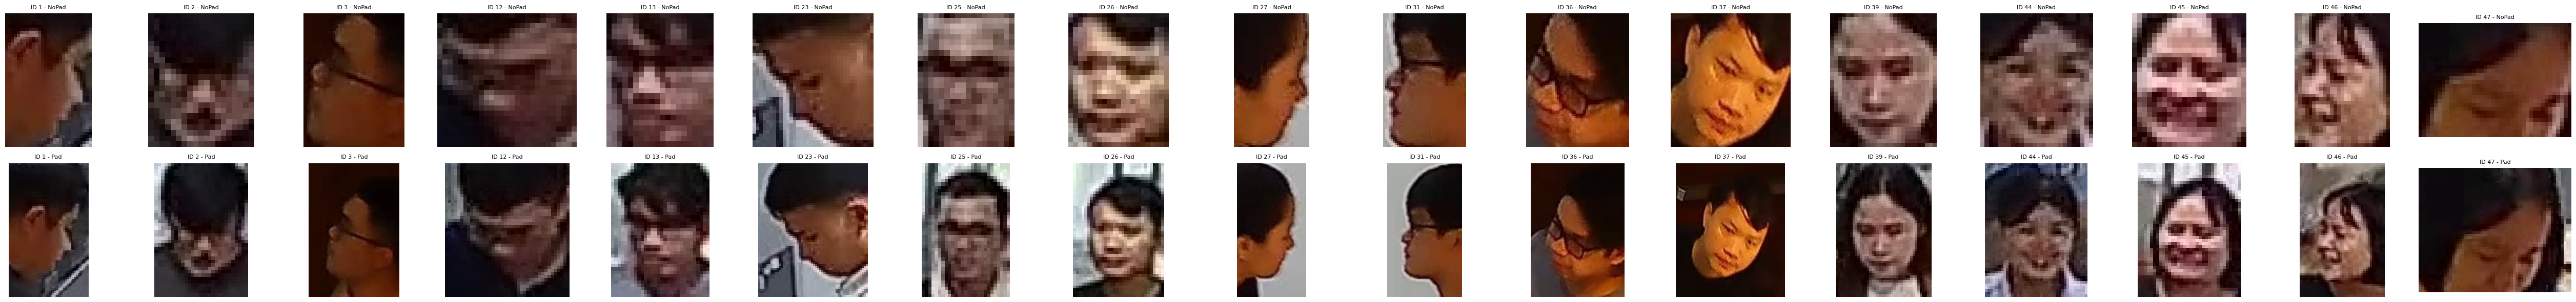

In [48]:
common_ids = sorted(set(groups_no.keys()) & set(groups_pad.keys()))
if not common_ids:
    print("Không tìm thấy ID trùng trong hai thư mục.")
else:
    selected_ids = common_ids[:NUM_SHOW_IDS]
    print(f"Có {len(common_ids)} ID trùng. Hiển thị {len(selected_ids)} ID đầu tiên.")
    plt.figure(figsize=(3 * len(selected_ids), 6))

    for idx, tid in enumerate(selected_ids):
        file_no = groups_no[tid][0][1]
        file_pad = groups_pad[tid][0][1]

        img_no = cv2.imread(os.path.join(FIRST_DIR, file_no))
        img_pad = cv2.imread(os.path.join(SECOND_DIR, file_pad))
        if img_no is None or img_pad is None:
            continue

        plt.subplot(2, len(selected_ids), idx + 1)
        plt.imshow(cv2.cvtColor(img_no, cv2.COLOR_BGR2RGB))
        plt.title(f"ID {tid} - NoPad", fontsize=8)
        plt.axis("off")

        plt.subplot(2, len(selected_ids), len(selected_ids) + idx + 1)
        plt.imshow(cv2.cvtColor(img_pad, cv2.COLOR_BGR2RGB))
        plt.title(f"ID {tid} - Pad", fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### `STEP 2: APPLY ROI`